In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    make_scorer,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
)

In [15]:
def get_data():
    """
    Function to load the ATP tennis matches dataset from 2004 to 2024.
    The dataset is hosted on GitHub and contains match statistics.
    """
    # URL for the dataset
    url = "https://github.com/JeffSackmann/tennis_atp/blob/master"

    # Load the dataset, going from 2004 to 2024 (picking only atp_matches_years.csv)
    years = list(range(2004, 2025))
    matches = []
    for year in years:
        file_url = f"{url}/atp_matches_{year}.csv?raw=true"
        df = pd.read_csv(file_url)
        matches.append(df)
    # Concatenate all dataframes into one
    matches_df = pd.concat(matches, ignore_index=True)
    # Reset index
    matches_df.reset_index(drop=True, inplace=True)

    # Turn all nan values into 0
    matches_df.fillna(0, inplace=True)

    FEATURES = [
        "w_ace",
        "w_1stWon",
        "w_2ndWon",
        "w_svpt",
        "best_of",
        # "l_ace", # Comment out when using the winner model
        # "l_1stWon",
    ]

    TARGET = [
        # "ace_diff",
        # "1stWon_diff",
        # "2ndWon_diff",
        # "svpt_diff",
        "ace_perc",
        "1stWon_perc",
        "2ndWon_perc",
        "svpt_perc",
    ]

    matches_df["ace_diff"] = (matches_df["w_ace"] - matches_df["l_ace"]) / matches_df[
        "best_of"
    ]
    matches_df["1stWon_diff"] = (
        matches_df["w_1stWon"] - matches_df["l_1stWon"]
    ) / matches_df["best_of"]
    matches_df["2ndWon_diff"] = (
        matches_df["w_2ndWon"] - matches_df["l_2ndWon"]
    ) / matches_df["best_of"]
    matches_df["svpt_diff"] = (
        matches_df["w_svpt"] - matches_df["l_svpt"]
    ) / matches_df["best_of"]

    matches_df["ace_perc"] = matches_df["w_ace"] / (
        matches_df["w_ace"] + matches_df["l_ace"]
    )
    matches_df["1stWon_perc"] = matches_df["w_1stWon"] / (
        matches_df["w_1stWon"] + matches_df["l_1stWon"]
    )
    matches_df["2ndWon_perc"] = matches_df["w_2ndWon"] / (
        matches_df["w_2ndWon"] + matches_df["l_2ndWon"]
    )
    matches_df["svpt_perc"] = matches_df["w_svpt"] / (
        matches_df["w_svpt"] + matches_df["l_svpt"]
    )

    X = matches_df[FEATURES]
    y = matches_df[TARGET]

    # Drop nan values
    combined = matches_df[FEATURES + TARGET].dropna()
    # Reset index
    X = combined[FEATURES].reset_index(drop=True)
    y = combined[TARGET].reset_index(drop=True)

    return X, y


def plot_data(X, y):
    """
    Function to plot the data using seaborn and matplotlib.
    """
    # Set the style of seaborn
    sns.set(style="whitegrid")

    # Create a pairplot for the features
    sns.pairplot(X)
    plt.show()

    # Create a heatmap for the correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()


def train_logistic_regression(X, y, cv_folds=5):
    """
    Train a logistic regression model with stratified K‑fold cross‑validation.
    Converts 'ace_perc' into a binary target (1 if >0.5, else 0).
    """
    # 1. Binarize the target
    y_binary = (y["ace_perc"] > 0.5).astype(int)

    # 2. Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binary, test_size=0.2, stratify=y_binary, random_state=42
    )

    # 3. Set up model & CV
    model = LogisticRegression(max_iter=1000, solver="liblinear")
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # 4. Cross‑validate for Accuracy & AUC
    scoring = {
        "accuracy": "accuracy",
        "roc_auc": make_scorer(roc_auc_score, needs_proba=True),
    }
    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
    )

    print(
        f"CV Accuracy: {cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}"
    )
    print(
        f"CV ROC‑AUC: {cv_results['test_roc_auc'].mean():.3f} ± {cv_results['test_roc_auc'].std():.3f}"
    )

    # 5. (Optional) Hyperparameter tuning example
    # Uncomment to search over C and penalty
    param_grid = {"C": [0.01, 0.1, 1, 10], "penalty": ["l1", "l2"]}
    grid = GridSearchCV(model, param_grid, cv=skf, scoring="roc_auc")
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    model = grid.best_estimator_

    # 6. Fit final model
    model.fit(X_train, y_train)

    # 7. Test‑set evaluation
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    test_acc = accuracy_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_proba)

    print(f"\nTest Accuracy: {test_acc:.3f}")
    print(f"Test ROC‑AUC:   {test_auc:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model


def predict(model, X):
    """
    Use the trained logistic regression model to make predictions.
    """
    return model.predict(X)


def plot_logistic_regression(model, X, y):
    # Choose "w_ace" as the variable of interest and hold others constant.
    # Calculate the average values for the other features.
    avg_1stWon = X["w_1stWon"].mean()
    avg_2ndWon = X["w_2ndWon"].mean()
    avg_w_svpt = X["w_svpt"].mean()
    avg_best_of = X["best_of"].mean()

    # Generate a range of values for "w_ace".
    w_ace_range = np.linspace(X["w_ace"].min(), X["w_ace"].max(), 100)

    # Create a DataFrame for predictions with all 5 features.
    synthetic_df = pd.DataFrame(
        {
            "w_ace": w_ace_range,
            "w_1stWon": avg_1stWon,
            "w_2ndWon": avg_2ndWon,
            "w_svpt": avg_w_svpt,
            "best_of": avg_best_of,
        }
    )

    # Use the model to predict probabilities.
    y_prob = model.predict_proba(synthetic_df)[:, 1]

    # Plot: Use w_ace as x-axis
    plt.figure(figsize=(10, 6))
    # For plotting actual data, use the binary target from your "ace_perc" threshold.
    plt.scatter(
        X["w_ace"], (y["ace_perc"] > 0.5).astype(int), alpha=0.5, label="Data Points"
    )
    plt.plot(w_ace_range, y_prob, color="red", label="Logistic Regression Curve")
    plt.xlabel("w_ace")
    plt.ylabel("Probability (ace_perc > 0.5)")
    plt.title("Effect of w_ace on Probability of High Ace Percentage")
    plt.legend()
    plt.show()

              w_ace      w_1stWon      w_2ndWon        w_svpt       best_of
count  56402.000000  56402.000000  56402.000000  56402.000000  56402.000000
mean       7.079589     36.842027     16.483990     78.266569      3.387398
std        5.581540     13.611859      6.887084     29.125651      0.790398
min        0.000000      0.000000      0.000000      3.000000      3.000000
25%        3.000000     27.000000     12.000000     57.000000      3.000000
50%        6.000000     34.000000     15.000000     73.000000      3.000000
75%       10.000000     44.000000     20.000000     95.000000      3.000000
max      113.000000    292.000000     82.000000    491.000000      5.000000
           ace_perc   1stWon_perc   2ndWon_perc     svpt_perc
count  56402.000000  56402.000000  56402.000000  56402.000000
mean       0.584079      0.535023      0.532327      0.488981
std        0.248408      0.060211      0.102327      0.043944
min        0.000000      0.000000      0.000000      0.200000
25%   

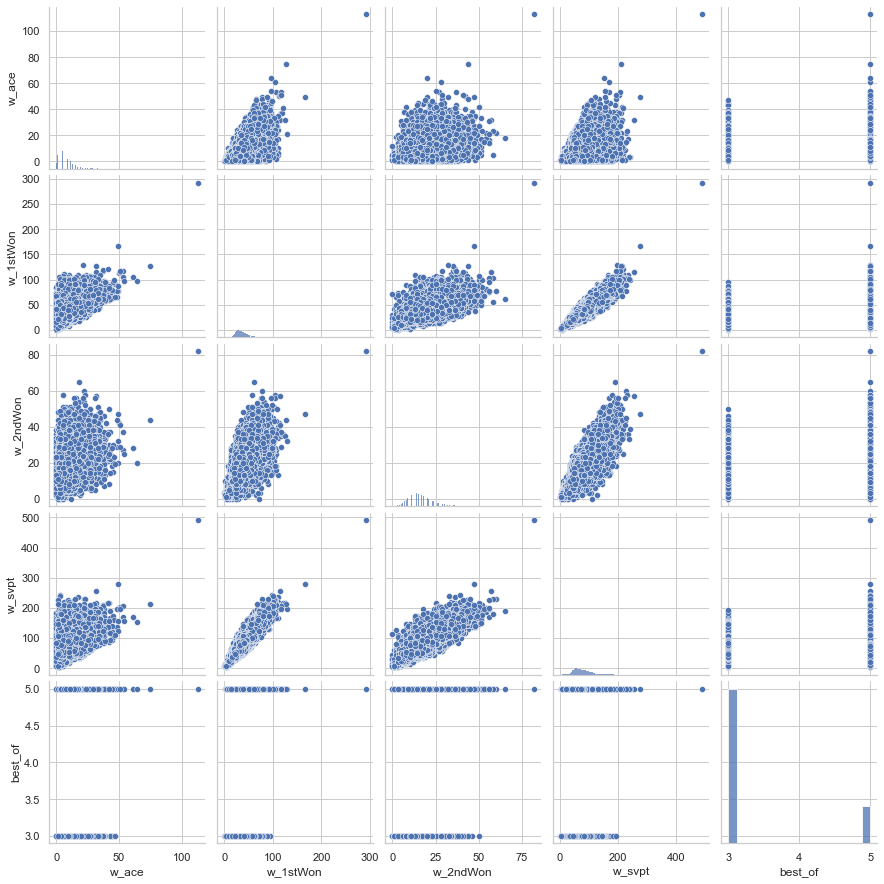

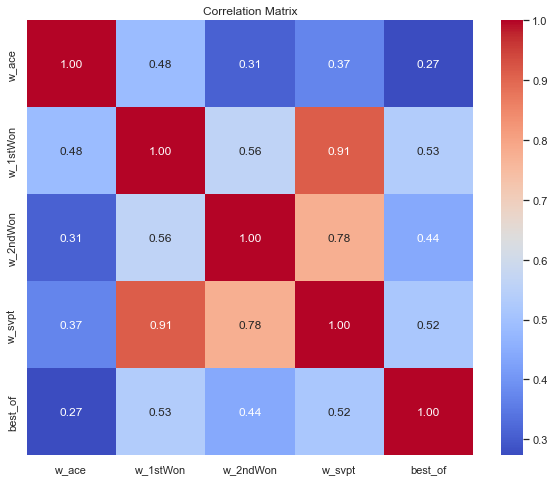

In [7]:
X, y = get_data()
# Check the data
print(X.describe())
print(y.describe())

# Plot the data
plot_data(X, y)

In [16]:
model = train_logistic_regression(X, y)
# Predict on the training set
predictions = predict(model, X)
# Print predictions
print("Predictions on training set:", predictions)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 388, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/_param_validation.py", line 194, in wrapper
    params = func_sig.bind(*args, **kwargs)
  File "/opt/anaconda3/lib/python3.9/inspect.py", line 3043, in bind
    return self._bind(args, kwargs)
  File "/opt/anaconda3/lib/python3.9/inspect.py", line 3032, in _bind
    raise TypeError(
TypeError: got an unexpected keyword argument 'needs_proba'

  warnings.warn(
/opt/anaconda3/lib/python3.9

CV Accuracy: 0.776 ± 0.005
CV ROC‑AUC: nan ± nan
Best params: {'C': 0.01, 'penalty': 'l2'}

Test Accuracy: 0.780
Test ROC‑AUC:   0.852

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.72      4503
           1       0.81      0.82      0.82      6778

    accuracy                           0.78     11281
   macro avg       0.77      0.77      0.77     11281
weighted avg       0.78      0.78      0.78     11281

Confusion Matrix:
[[3220 1283]
 [1196 5582]]
Predictions on training set: [1 1 1 ... 1 0 0]


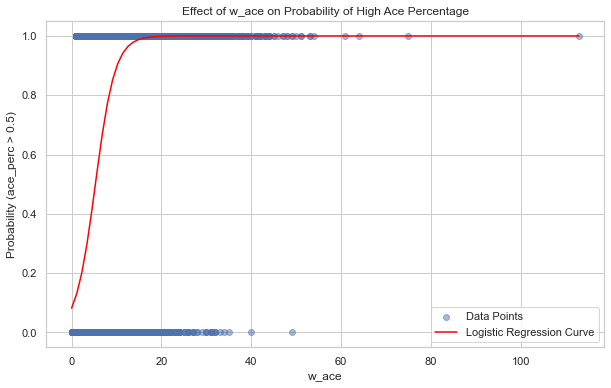

In [17]:
# Plot the logistic regression model
plot_logistic_regression(model, X, y)